# Histogram of Oriented Gradients (HOG)

In [1]:
# Library Declarations
import time
import random
import numpy as np
import pandas as pd
import os

from matplotlib import pyplot as plt
from skimage import io, color
from skimage.transform import resize
from math import floor

## Configuration

In [2]:
RUN_SW = False
RUN_HW = True

CELL_W = 30
CELL_H = 30
NUM_BINS = 9

# Match in gradient_convolution.h
IMG_H = 300
IMG_W = 300
MAX_IMG_H = 500
MAX_IMG_W = 500

IMAGE_PATH = './ref.png'
NUM_IMAGES = 10

INT_TYPE = np.uint32
FLOAT_TYPE = np.float64

# Modify according to Vivado file
ADDRESS_RANGE     = 0x10000
ADDR_OFFSET_HOG  = 0x40000000
ADDR_IMAGE_LOW   = 0x10   # image pointer lower 32 bits
ADDR_IMAGE_HIGH  = 0x14   # image pointer upper 32 bits
ADDR_HISTS_LOW   = 0x1C   # all_hists pointer lower 32 bits
ADDR_HISTS_HIGH  = 0x20   # all_hists pointer upper 32 bits
ADDR_ROWS        = 0x28   # rows scalar
ADDR_COLS        = 0x30   # cols scalar

####### DO NOT CHANGE
CTRL_ADDR       = 0x00  # Control register address
START_VALUE     = 1<<0  # bit 0
STOP_VALUE      = 0x0   # bit 0
DONE_VALUE      = 1<<1  # bit 1
AUTO_RESTART    = 1<<7  # bit 7

AP_START = 0x01
AP_DONE  = 0x02
AP_IDLE  = 0x04

## Additional Hardware Configurations

In [3]:
if RUN_HW:
    from pynq import Overlay, allocate, MMIO
    ol = Overlay('./hog_accel.bit')
    hog_ip = MMIO(ADDR_OFFSET_HOG, ADDRESS_RANGE)
    print("Overlay loaded.")

Overlay loaded.


## Software HOG

In [4]:
# Preprocessing
def preprocess(raw_image):
    # convert to grayscale if needed
    if raw_image.ndim == 3:
        image = color.rgb2gray(raw_image)
    else:
        image = raw_image.astype(np.float64)

    # normalize to [0, 1]
    image = image / 255.0 if image.max() > 1.0 else image

    # crop to largest dimensions divisible by cell size
    # this must happen BEFORE sending to hardware
    H, W   = image.shape
    new_H  = (H // CELL_H) * CELL_H
    new_W  = (W // CELL_W) * CELL_W

    # also enforce hardware maximum
    new_H  = min(new_H, MAX_IMG_H)
    new_W  = min(new_W, MAX_IMG_W)

    image  = image[:new_H, :new_W]

    return image

# Convolution
def convolution_python(image, kernel):
    ir, jr = image.shape
    result = np.copy(image)
    for i in range(1, ir - 1):
        for j in range(1, jr - 1):
            result[i, j] = np.sum(image[i-1:i+2, j-1:j+2] * kernel)
    return result

def compute_gradients(image):
    kernel_dx = np.array([[0,0,0],[-1,0,1],[0,0,0]])
    kernel_dy = np.array([[0,-1,0],[0,0,0],[0,1,0]])
    ix = convolution_python(image, kernel_dx)
    iy = convolution_python(image, kernel_dy)
    g = np.sqrt(ix**2 + iy**2)
    return ix, iy, g

# Orientation Computation
def compute_orientation(ix, iy):
    # Return signed gradient orientation in degrees [0,360)
    theta = np.degrees(np.arctan2(iy, ix))
    theta[theta < 0] += 360
    return theta

# Cell Histogram Calculation
def compute_cell_histograms(theta, w, h, num_bins):
    hs, ws = theta.shape
    ir, jr = floor(hs/h) + 1, floor(ws/w) + 1
    histograms = [[None] * jr for _ in range(ir)]
    for i in range(ir):
        for j in range(jr):
            patch = theta[i*h : i*h + h, j*w : j*w + w]
            histograms[i][j] = np.histogram(patch, bins=num_bins, range=(0,360))[0]
    return histograms

def hog(raw_image, w=CELL_W, h=CELL_H, num_bins=NUM_BINS):
    timings = {}

    # Preprocessing
    t0 = time.perf_counter()
    image = preprocess(raw_image)
    timings['preprocess'] = (time.perf_counter() - t0) * 1e3

    # Convolution
    t0 = time.perf_counter()
    ix, iy, g = compute_gradients(image)
    timings['convolution'] = (time.perf_counter() - t0) * 1e3

    # Orientation
    t0 = time.perf_counter()
    theta = compute_orientation(ix, iy)
    timings['orientation'] = (time.perf_counter() - t0) * 1e3

    # Cell histograms
    t0 = time.perf_counter()
    histograms = compute_cell_histograms(theta, w, h, num_bins)
    timings['cell_histograms'] = (time.perf_counter() - t0) * 1e3

    return histograms, timings

print("Building blocks defined.")

Building blocks defined.


## Load and Inspect Images

person_058.png shape: (480, 640, 3)
person_058.png dtype: uint8


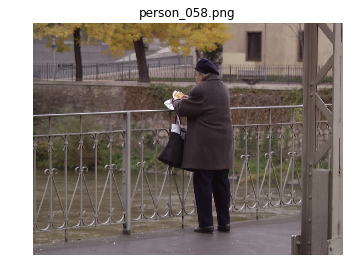

person_317.png shape: (480, 640, 3)
person_317.png dtype: uint8


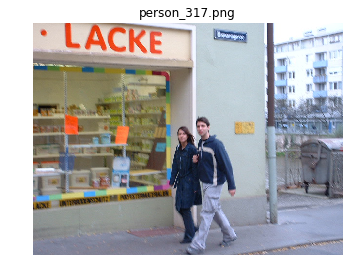

person_318.png shape: (480, 640, 3)
person_318.png dtype: uint8


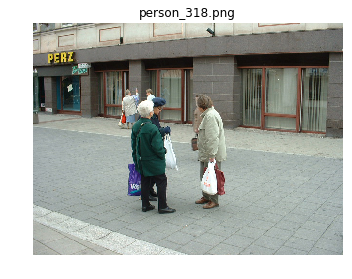

person_323.png shape: (480, 640, 3)
person_323.png dtype: uint8


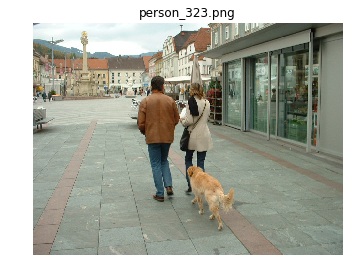

person_325.png shape: (480, 640, 3)
person_325.png dtype: uint8


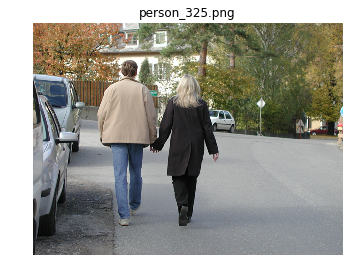

person_335.png shape: (480, 640, 3)
person_335.png dtype: uint8
person_336.png shape: (480, 640, 3)
person_336.png dtype: uint8
person_337.png shape: (480, 640, 3)
person_337.png dtype: uint8
person_347.png shape: (480, 640, 3)
person_347.png dtype: uint8
person_350.png shape: (480, 640, 3)
person_350.png dtype: uint8

Loaded 10 images from ./INRIAPerson


In [5]:
from skimage.color import rgb2gray

INRIA_DIR = "./INRIAPerson"
TARGET_SHAPE = (300, 300)

inria_files = sorted([
    f for f in os.listdir(INRIA_DIR)
    if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))
])

inria_images = {}

for i, fname in enumerate(inria_files):
    path = os.path.join(INRIA_DIR, fname)

    raw_image = io.imread(path)
    print(f"{fname} shape: {raw_image.shape}")
    print(f"{fname} dtype: {raw_image.dtype}")

    # Show image (only first few so you don’t flood output)
    if i < 5:
        plt.figure(figsize=(5, 4))
        plt.imshow(raw_image, cmap='gray' if raw_image.ndim == 2 else None)
        plt.title(fname)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    # Resize (compatible with your skimage version)
    img_resized = resize(
        raw_image,
        TARGET_SHAPE,
        preserve_range=True,
        mode='reflect'
    ).astype(np.uint8)

    inria_images[fname] = img_resized

print(f"\nLoaded {len(inria_images)} images from {INRIA_DIR}")

## Input Image for Software Profiling

Image shape: (217, 262)
Image dtype: float64


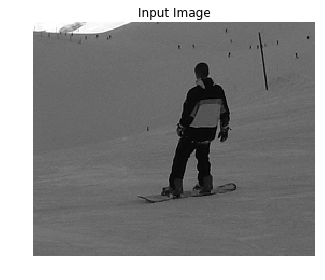

In [6]:
raw_image = io.imread(IMAGE_PATH)

if raw_image.ndim == 3:
    raw_image = color.rgb2gray(raw_image)

height, width = raw_image.shape

print(f"Image shape: {raw_image.shape}")
print(f"Image dtype: {raw_image.dtype}")

plt.figure(figsize=(5, 4))
plt.imshow(raw_image, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## SoftwareProfiling

In [7]:
if RUN_SW:
    print("--- Starting Software Profiling ---")

    all_timings = []
    for i in range(NUM_IMAGES):
        _, t = hog(raw_image, CELL_W, CELL_H, NUM_BINS)
        all_timings.append(t)

    stages = list(all_timings[0].keys())
    avg_t = {s: np.mean([r[s] for r in all_timings]) for s in stages}
    total = sum(avg_t.values())

    print(f"\nAverage over {NUM_IMAGES} runs (ms):")
    for s, v in avg_t.items():
        pct = 100 * v / total
        print(f"  {s:<20}: {v:8.3f} ms  ({pct:.1f}%)")
    print(f"  {'TOTAL':<20}: {total:8.3f} ms")

    # Bar chart
    colors = ['blue', 'red', 'green', 'yellow']

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(stages, [avg_t[s] for s in stages], color=colors)

    for bar, s in zip(bars, stages):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{avg_t[s]:.2f} ms',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_ylabel('Time (ms)')
    ax.set_title('Latency Contribution of Pipeline Stages')
    plt.tight_layout()
    plt.show()

## Visualize Intermediate Outputs

In [8]:
if RUN_SW:
    image = preprocess(raw_image)
    ix, iy, g = compute_gradients(image)
    theta = compute_orientation(ix, iy)
    gc = np.where(theta <= 180, 1, 0)  # orientation class map

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titles = ['Gradient According to X', 'Gradient According to Y', 'Magnitude G', 'Orientation Class']
    imgs = [ix, iy, g, gc]
    for ax, title, img in zip(axes, titles, imgs):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    '''# Cell histogram grid
    histograms, _ = hog(raw_image, CELL_W, CELL_H, NUM_BINS)
    il = len(histograms)
    jl = len(histograms[0])
    fig, axes = plt.subplots(il, jl, figsize=(jl * 2, il * 2))
    for i in range(il):
        for j in range(jl):
            ax = axes[i][j] if il > 1 else axes[j]
            ax.bar(range(NUM_BINS), histograms[i][j], color='steelblue')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.suptitle(f'Cell Histograms ({il}×{jl} grid, {NUM_BINS} bins each)')
    plt.tight_layout()
    plt.show()'''

## Hardware-Accelerated HOG

In [9]:
def preprocess(raw_image):
        if raw_image.ndim == 3:
            image = color.rgb2gray(raw_image)
        else:
            image = raw_image.astype(np.float64)
        image = image / 255.0 if image.max() > 1.0 else image
        H, W  = image.shape
        # floor to cell boundary AND enforce hardware max
        new_H = (min(H, MAX_IMG_H) // CELL_H) * CELL_H
        new_W = (min(W, MAX_IMG_W) // CELL_W) * CELL_W
        return image[:new_H, :new_W]

def hog_accel_hw(image):
    H, W = image.shape
    image_hw    = (image * 255).clip(0, 255).astype(np.uint8)
    num_cells_y = H // CELL_H
    num_cells_x = W // CELL_W
    num_cells   = num_cells_y * num_cells_x

    img_buf  = allocate(shape=(H * W,),               dtype=np.uint8)
    hist_buf = allocate(shape=(num_cells * NUM_BINS,), dtype=np.int32)

    np.copyto(img_buf, image_hw.flatten())
    hist_buf[:] = 0
    img_buf.flush()
    hist_buf.flush()

    hog_ip.write(ADDR_IMAGE_LOW,  img_buf.physical_address        & 0xFFFFFFFF)
    hog_ip.write(ADDR_IMAGE_HIGH, (img_buf.physical_address >> 32) & 0xFFFFFFFF)
    hog_ip.write(ADDR_HISTS_LOW,  hist_buf.physical_address        & 0xFFFFFFFF)
    hog_ip.write(ADDR_HISTS_HIGH, (hist_buf.physical_address >> 32) & 0xFFFFFFFF)
    hog_ip.write(ADDR_ROWS, H)
    hog_ip.write(ADDR_COLS, W)

    hog_ip.write(CTRL_ADDR, START_VALUE)
    while not (hog_ip.read(CTRL_ADDR) & DONE_VALUE):
        pass

    hist_buf.invalidate()

    # direct histogram output — orientation and cell binning
    # happen inside hog_accel, so no numpy arctan2 needed here
    histograms = np.array(hist_buf, dtype=np.float64).reshape(
        num_cells_y, num_cells_x, NUM_BINS
    )

    img_buf.freebuffer()
    hist_buf.freebuffer()
    return histograms

def hog_hw(raw_image):
    timings = {}
    t0 = time.perf_counter()
    image = preprocess(raw_image)
    timings['preprocess (ARM)'] = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    histograms = hog_accel_hw(image)
    timings['hog_accel (FPGA)'] = (time.perf_counter() - t0) * 1000

    timings['TOTAL'] = sum(timings.values())
    return histograms, timings

print("Done.")

Done.


## Input Image for Hardware Profiling

Image shape: (217, 262)
Image dtype: float64


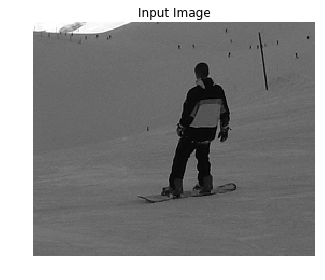

In [10]:
raw_image = io.imread(IMAGE_PATH)

if raw_image.ndim == 3:
    raw_image = color.rgb2gray(raw_image)

height, width = raw_image.shape

print(f"Image shape: {raw_image.shape}")
print(f"Image dtype: {raw_image.dtype}")

plt.figure(figsize=(5, 4))
plt.imshow(raw_image, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## Hardware Profiling

--- Starting Hardware Profiling ---

Hardware average over 10 runs (ms):
  preprocess (ARM)         :    3.397 ms  (28.1%)
  hog_accel (FPGA)         :    8.700 ms  (71.9%)
  TOTAL                    :   12.097 ms


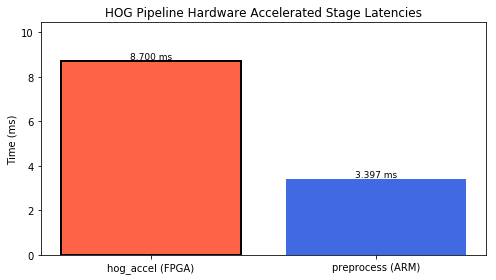

In [11]:
if RUN_HW:
    POLL_TIMEOUT_S = 30.0  # was 5.0 — too short for 330x480 DMA transfer

    
    #this sets our image size to be the same as our other profiling baselines to give us a fair speedup
    def preprocess_profile(raw_image):
        if raw_image.ndim == 3:
            image = color.rgb2gray(raw_image)
        else:
            image = raw_image.astype(np.float64)
        image = image / 255.0 if image.max() > 1.0 else image
        H, W  = image.shape
        return image[:120, :160]

    
    def hog_hw_profile(raw_image):
        timings = {}
        t0 = time.perf_counter()
        image = preprocess_profile(raw_image)
        timings['preprocess (ARM)'] = (time.perf_counter() - t0) * 1000

        t0 = time.perf_counter()
        histograms = hog_accel_hw(image)
        timings['hog_accel (FPGA)'] = (time.perf_counter() - t0) * 1000

        timings['TOTAL'] = sum(timings.values())
        return histograms, timings

    print("--- Starting Hardware Profiling ---")

    raw_image_hw = io.imread(IMAGE_PATH)

    test_image = preprocess(raw_image_hw)
    H, W = test_image.shape 
    _, t_test = hog_hw(raw_image_hw)

    hw_timings = []

    for i in range(NUM_IMAGES):
        _, t_hw = hog_hw_profile(raw_image)
        hw_timings.append(t_hw)

    stages_hw = [k for k in hw_timings[0].keys() if k != 'TOTAL']
    avg_hw = {s: np.mean([r[s] for r in hw_timings]) for s in stages_hw}
    total_hw = sum(avg_hw.values())

    print(f"\nHardware average over {NUM_IMAGES} runs (ms):")
    for s, v in avg_hw.items():
        pct = 100 * v / total_hw
        print(f"  {s:<25}: {v:8.3f} ms  ({pct:.1f}%)")
    print(f"  {'TOTAL':<25}: {total_hw:8.3f} ms")

#Create the bar chart
    colors = ['royalblue', 'tomato']

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(stages_hw, [avg_hw[s] for s in stages_hw], color=colors)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f} ms',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_ylabel('Time (ms)')
    ax.set_title('HOG Pipeline Hardware Accelerated Stage Latencies')

    fpga_idx = next(i for i, s in enumerate(stages_hw) if "FPGA" in s)
    bars[fpga_idx].set_edgecolor('black')
    bars[fpga_idx].set_linewidth(2)

    ax.set_ylim(0, max(avg_hw[s] for s in stages_hw) * 1.2)

    plt.tight_layout()
    plt.show()


# Compute Similarity

## Similarity Functions

In [12]:
# Flatten HOG feature vector
def flatten_hog(histograms):
    rows = []
    for row in histograms:
        for cell in row:
            rows.append(cell)
    return np.concatenate(rows)

# Similarity
def euclidean_metric(x, y):
    return np.linalg.norm(x - y)

def cosine_similarity(x, y):
    norm = np.linalg.norm(x) * np.linalg.norm(y)
    return 0.0 if norm == 0 else float(np.dot(x,y)/norm)

def similarity(img1, img2, w, h, num_bins, metric):
    hog1 = hog(img1, w, h, num_bins)[0]
    hog2 = hog(img2, w, h, num_bins)[0]
    return euclidean_metric(flatten_hog(hog1), flatten_hog(hog2))

## Import Reference Image

Reference image shape: (217, 262, 4)
Reference image dtype: uint8


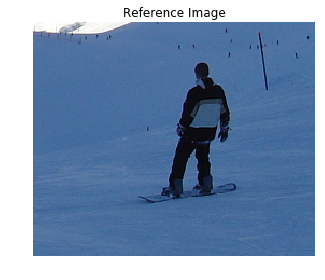

In [13]:
REF_PATH = "ref.png"
REFERENCE_IMAGE = REF_PATH
ref_raw = io.imread(REF_PATH)

print("Reference image shape:", ref_raw.shape)
print("Reference image dtype:", ref_raw.dtype)

plt.figure(figsize=(5, 4))
plt.imshow(ref_raw, cmap='gray' if ref_raw.ndim == 2 else None)
plt.title("Reference Image")
plt.axis("off")
plt.tight_layout()
plt.show()

## Deploying on PYNQ

--- Hardware HOG on INRIAPerson dataset ---

--- Hardware HOG on reference image ---


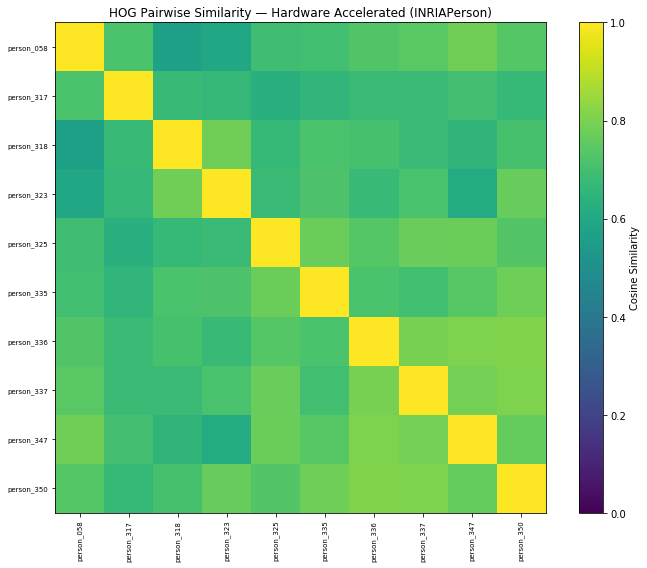

In [14]:
if RUN_HW:
    print("--- Hardware HOG on INRIAPerson dataset ---")

    H, W        = TARGET_SHAPE
    num_cells_y = H // CELL_H
    num_cells_x = W // CELL_W
    num_cells   = num_cells_y * num_cells_x

    img_buf  = allocate(shape=(H * W,), dtype=np.uint8)
    hist_buf = allocate(shape=(num_cells * NUM_BINS,), dtype=np.int32)

    hog_vectors_hw = {}
    hw_accel_times = []

    def run_hw_hog(img, label):
        image = preprocess(img)

        # Safety check in case preprocess does not force TARGET_SHAPE
        if image.shape != TARGET_SHAPE:
            image = resize(
                image,
                TARGET_SHAPE,
                preserve_range=True,
                mode='reflect'
            )

        # If preprocess returns 0 to 1 floats, scale to uint8
        # If it already returns 0 to 255, this still clips safely
        if image.max() <= 1.0:
            image_hw = (image * 255).clip(0, 255).astype(np.uint8)
        else:
            image_hw = image.clip(0, 255).astype(np.uint8)

        np.copyto(img_buf, image_hw.flatten())
        hist_buf[:] = 0

        img_buf.flush()
        hist_buf.flush()

        hog_ip.write(ADDR_IMAGE_LOW,  img_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_IMAGE_HIGH, (img_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_HISTS_LOW,  hist_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_HISTS_HIGH, (hist_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_ROWS, H)
        hog_ip.write(ADDR_COLS, W)

        t0 = time.perf_counter()
        hog_ip.write(CTRL_ADDR, START_VALUE)

        while not (hog_ip.read(CTRL_ADDR) & DONE_VALUE):
            pass

        elapsed_ms = (time.perf_counter() - t0) * 1e3

        hist_buf.invalidate()

        histograms = np.array(hist_buf, dtype=np.float64).reshape(
            num_cells_y, num_cells_x, NUM_BINS
        )

        hog_vec = flatten_hog(histograms)

        return hog_vec, elapsed_ms

    # Run INRIAPerson images
    for fname, img in inria_images.items():
        hog_vec, elapsed_ms = run_hw_hog(img, fname)

        hog_vectors_hw[fname] = hog_vec
        hw_accel_times.append(elapsed_ms)

    # Run reference image at the end
    print("\n--- Hardware HOG on reference image ---")

    ref_img = io.imread(REF_PATH)

    reference_hog_vector, ref_time_ms = run_hw_hog(ref_img, REF_PATH)

    hog_vectors_hw[REF_PATH] = reference_hog_vector


    img_buf.freebuffer()
    hist_buf.freebuffer()


    # Pairwise cosine similarity for only INRIAPerson images
    names = list(inria_images.keys())

    n = len(names)
    cosine_matrix_hw = np.zeros((n, n))

    for i, n1 in enumerate(names):
        for j, n2 in enumerate(names):
            cosine_matrix_hw[i, j] = cosine_similarity(
                hog_vectors_hw[n1],
                hog_vectors_hw[n2]
            )

    fig, ax = plt.subplots(figsize=(max(8, n), max(6, n - 2)))
    im = ax.imshow(cosine_matrix_hw, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Cosine Similarity')

    short_names = [os.path.splitext(f)[0] for f in names]

    ax.set_xticks(range(n))
    ax.set_xticklabels(short_names, rotation=90, fontsize=7)

    ax.set_yticks(range(n))
    ax.set_yticklabels(short_names, fontsize=7)

    ax.set_title('HOG Pairwise Similarity — Hardware Accelerated (INRIAPerson)')

    plt.tight_layout()
    plt.show()

## HOG with No Human Dataset

--- Hardware HOG comparison against reference image (nohuman set) ---
12218.jpg                      similarity = 0.2893
12220.jpg                      similarity = 0.3230
12222.jpg                      similarity = 0.2723
12230.jpg                      similarity = 0.4052
12237.jpg                      similarity = 0.4873
12337.jpg                      similarity = 0.4320
12339.jpg                      similarity = 0.3304
12344.jpg                      similarity = 0.3121
12353.jpg                      similarity = 0.4510
12368.jpg                      similarity = 0.4616
12381.jpg                      similarity = 0.4401
12383.jpg                      similarity = 0.3786


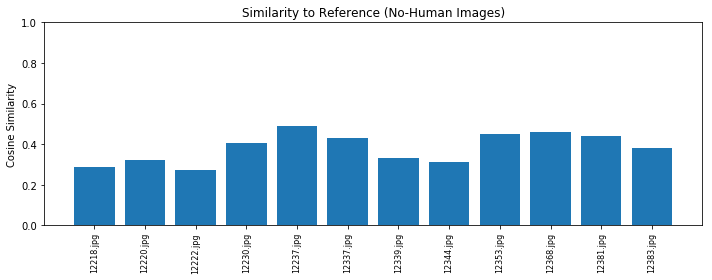

In [15]:
from skimage.transform import resize

NOHUMAN_DIR = "./nohuman"

nohuman_files = sorted([
    f for f in os.listdir(NOHUMAN_DIR)
    if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))
])

nohuman_images = {}
for fname in nohuman_files:
    path = os.path.join(NOHUMAN_DIR, fname)
    nohuman_images[fname] = io.imread(path)

if RUN_HW:
    print("--- Hardware HOG comparison against reference image (nohuman set) ---")

    H, W        = TARGET_SHAPE
    num_cells_y = H // CELL_H
    num_cells_x = W // CELL_W
    num_cells   = num_cells_y * num_cells_x

    img_buf  = allocate(shape=(H * W,), dtype=np.uint8)
    hist_buf = allocate(shape=(num_cells * NUM_BINS,), dtype=np.int32)

    nohuman_scores = {}
    hw_accel_times = []

    reference_hog_vector = hog_vectors_hw[REFERENCE_IMAGE]

    for fname, img in nohuman_images.items():
        image = preprocess(img)

        if image.shape != TARGET_SHAPE:
            image = resize(
                image,
                TARGET_SHAPE,
                preserve_range=True,
                mode='reflect'
            )

        image_hw = (image * 255).clip(0, 255).astype(np.uint8)

        np.copyto(img_buf, image_hw.flatten())
        hist_buf[:] = 0

        img_buf.flush()
        hist_buf.flush()

        hog_ip.write(ADDR_IMAGE_LOW,  img_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_IMAGE_HIGH, (img_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_HISTS_LOW,  hist_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_HISTS_HIGH, (hist_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_ROWS, H)
        hog_ip.write(ADDR_COLS, W)

        t0 = time.perf_counter()
        hog_ip.write(CTRL_ADDR, START_VALUE)

        while not (hog_ip.read(CTRL_ADDR) & DONE_VALUE):
            pass

        hw_accel_times.append((time.perf_counter() - t0) * 1e3)

        hist_buf.invalidate()

        histograms = np.array(hist_buf, dtype=np.float64).reshape(
            num_cells_y, num_cells_x, NUM_BINS
        )

        hog_vec = flatten_hog(histograms)

        score = cosine_similarity(reference_hog_vector, hog_vec)
        nohuman_scores[fname] = score

        print(f"{fname:<30} similarity = {score:.4f}")

    img_buf.freebuffer()
    hist_buf.freebuffer()

    names = list(nohuman_scores.keys())
    scores = list(nohuman_scores.values())

    plt.figure(figsize=(10, 4))
    plt.bar(names, scores)
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Cosine Similarity")
    plt.title("Similarity to Reference (No-Human Images)")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    

## HOG with All Human Dataset

--- Hardware HOG comparison against reference image ---
person_058.png                 similarity = 0.5425
person_317.png                 similarity = 0.5969
person_318.png                 similarity = 0.5243
person_323.png                 similarity = 0.5843
person_325.png                 similarity = 0.4088
person_335.png                 similarity = 0.4812
person_336.png                 similarity = 0.5331
person_337.png                 similarity = 0.5549
person_347.png                 similarity = 0.5229
person_350.png                 similarity = 0.5716


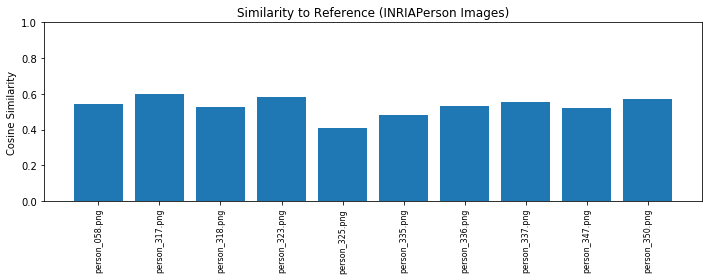

In [16]:
if RUN_HW:
    print("--- Hardware HOG comparison against reference image ---")

    H, W        = TARGET_SHAPE
    num_cells_y = H // CELL_H
    num_cells_x = W // CELL_W
    num_cells   = num_cells_y * num_cells_x

    img_buf  = allocate(shape=(H * W,), dtype=np.uint8)
    hist_buf = allocate(shape=(num_cells * NUM_BINS,), dtype=np.int32)

    inria_scores = {}
    hw_accel_times = []

    reference_hog_vector = hog_vectors_hw[REFERENCE_IMAGE]

    for fname, img in inria_images.items():
        image    = preprocess(img)
        image_hw = (image * 255).clip(0, 255).astype(np.uint8)

        np.copyto(img_buf, image_hw.flatten())
        hist_buf[:] = 0

        img_buf.flush()
        hist_buf.flush()

        hog_ip.write(ADDR_IMAGE_LOW,  img_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_IMAGE_HIGH, (img_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_HISTS_LOW,  hist_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_HISTS_HIGH, (hist_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_ROWS, H)
        hog_ip.write(ADDR_COLS, W)

        t0 = time.perf_counter()
        hog_ip.write(CTRL_ADDR, START_VALUE)

        while not (hog_ip.read(CTRL_ADDR) & DONE_VALUE):
            pass

        hw_accel_times.append((time.perf_counter() - t0) * 1e3)

        hist_buf.invalidate()

        histograms = np.array(hist_buf, dtype=np.float64).reshape(
            num_cells_y, num_cells_x, NUM_BINS
        )

        hog_vec = flatten_hog(histograms)

        score = cosine_similarity(reference_hog_vector, hog_vec)
        inria_scores[fname] = score

        print(f"{fname:<30} similarity = {score:.4f}")

    img_buf.freebuffer()
    hist_buf.freebuffer()


    names = list(inria_scores.keys())
    scores = list(inria_scores.values())

    plt.figure(figsize=(10, 4))
    plt.bar(names, scores)
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Cosine Similarity")
    plt.title("Similarity to Reference (INRIAPerson Images)")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

## HOG similarity test on unknown set of images

--- Best Baseline Threshold Search ---
Best threshold: 0.4632
Training accuracy: 90.91%
--- Hardware HOG comparison against reference image (test set) ---
human-1.jpg                    similarity = 0.4343  -->  NO HUMAN
human-10.jpg                   similarity = 0.5093  -->  HUMAN
human-2.jpg                    similarity = 0.5183  -->  HUMAN
human-3.jpg                    similarity = 0.4198  -->  NO HUMAN
human-4.jpg                    similarity = 0.5723  -->  HUMAN
human-5.jpg                    similarity = 0.4818  -->  HUMAN
human-6.jpg                    similarity = 0.5692  -->  HUMAN
human-7.jpg                    similarity = 0.5756  -->  HUMAN
human-8.jpg                    similarity = 0.5299  -->  HUMAN
human-9.jpg                    similarity = 0.5762  -->  HUMAN
no-1.jpg                       similarity = 0.4239  -->  NO HUMAN
no-10.jpg                      similarity = 0.3707  -->  NO HUMAN
no-2.jpg                       similarity = 0.2506  -->  NO HUMAN
no-3.jpg   

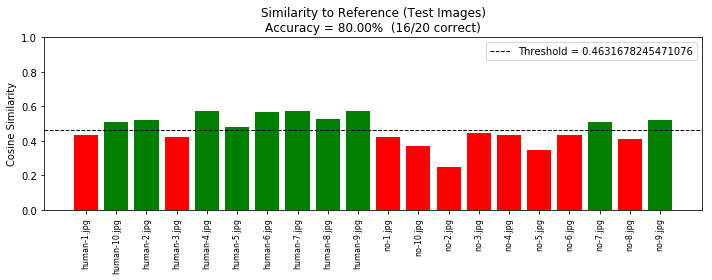


--- Classification Accuracy ---
Correct predictions: 16/20
Accuracy: 80.00%

--- Per-Image Results ---
human-1.jpg                    true = HUMAN    predicted = NO HUMAN score = 0.4343  WRONG
human-10.jpg                   true = HUMAN    predicted = HUMAN    score = 0.5093  CORRECT
human-2.jpg                    true = HUMAN    predicted = HUMAN    score = 0.5183  CORRECT
human-3.jpg                    true = HUMAN    predicted = NO HUMAN score = 0.4198  WRONG
human-4.jpg                    true = HUMAN    predicted = HUMAN    score = 0.5723  CORRECT
human-5.jpg                    true = HUMAN    predicted = HUMAN    score = 0.4818  CORRECT
human-6.jpg                    true = HUMAN    predicted = HUMAN    score = 0.5692  CORRECT
human-7.jpg                    true = HUMAN    predicted = HUMAN    score = 0.5756  CORRECT
human-8.jpg                    true = HUMAN    predicted = HUMAN    score = 0.5299  CORRECT
human-9.jpg                    true = HUMAN    predicted = HUMAN    scor

In [17]:
TEST_DIR = "./test"

human_train_scores = list(inria_scores.values())
nohuman_train_scores = list(nohuman_scores.values())

train_scores = human_train_scores + nohuman_train_scores
train_labels = (
    ["HUMAN"] * len(human_train_scores) +
    ["NO HUMAN"] * len(nohuman_train_scores)
)

candidate_thresholds = np.linspace(
    min(train_scores),
    max(train_scores),
    200
)

best_threshold = None
best_accuracy = 0

for threshold in candidate_thresholds:
    pred_labels = [
        "HUMAN" if score > threshold else "NO HUMAN"
        for score in train_scores
    ]

    correct = sum([
        pred == true
        for pred, true in zip(pred_labels, train_labels)
    ])

    accuracy = correct / len(train_labels)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

print("--- Best Baseline Threshold Search ---")
print(f"Best threshold: {best_threshold:.4f}")
print(f"Training accuracy: {best_accuracy * 100:.2f}%")

THRESHOLD = best_threshold

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))
])

test_images = {}
for fname in test_files:
    path = os.path.join(TEST_DIR, fname)
    test_images[fname] = io.imread(path)


if RUN_HW:
    print("--- Hardware HOG comparison against reference image (test set) ---")

    H, W        = TARGET_SHAPE
    num_cells_y = H // CELL_H
    num_cells_x = W // CELL_W
    num_cells   = num_cells_y * num_cells_x

    img_buf  = allocate(shape=(H * W,), dtype=np.uint8)
    hist_buf = allocate(shape=(num_cells * NUM_BINS,), dtype=np.int32)

    test_scores = {}
    hw_accel_times = []

    reference_hog_vector = hog_vectors_hw[REFERENCE_IMAGE]

    for fname, img in test_images.items():
        image = preprocess(img)

        # Make sure image matches hardware input size
        if image.shape != TARGET_SHAPE:
            image = resize(
                image,
                TARGET_SHAPE,
                preserve_range=True,
                mode='reflect'
            )

        image_hw = (image * 255).clip(0, 255).astype(np.uint8)

        np.copyto(img_buf, image_hw.flatten())
        hist_buf[:] = 0

        img_buf.flush()
        hist_buf.flush()

        hog_ip.write(ADDR_IMAGE_LOW,  img_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_IMAGE_HIGH, (img_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_HISTS_LOW,  hist_buf.physical_address & 0xFFFFFFFF)
        hog_ip.write(ADDR_HISTS_HIGH, (hist_buf.physical_address >> 32) & 0xFFFFFFFF)

        hog_ip.write(ADDR_ROWS, H)
        hog_ip.write(ADDR_COLS, W)

        t0 = time.perf_counter()
        hog_ip.write(CTRL_ADDR, START_VALUE)

        while not (hog_ip.read(CTRL_ADDR) & DONE_VALUE):
            pass

        hw_accel_times.append((time.perf_counter() - t0) * 1e3)

        hist_buf.invalidate()

        histograms = np.array(hist_buf, dtype=np.float64).reshape(
            num_cells_y, num_cells_x, NUM_BINS
        )

        hog_vec = flatten_hog(histograms)

        score = cosine_similarity(reference_hog_vector, hog_vec)
        test_scores[fname] = score

        label = "HUMAN" if score > THRESHOLD else "NO HUMAN"
        print(f"{fname:<30} similarity = {score:.4f}  -->  {label}")

    img_buf.freebuffer()
    hist_buf.freebuffer()

    names = list(test_scores.keys())
    scores = list(test_scores.values())

    pred_labels = [
        "HUMAN" if score > THRESHOLD else "NO HUMAN"
        for score in scores
    ]

    # First 10 images are human, last 10 images are no-human
    true_labels = [
        "HUMAN" if i < 10 else "NO HUMAN"
        for i in range(len(names))
    ]

    correct = sum([
        true_label == pred_label
        for true_label, pred_label in zip(true_labels, pred_labels)
    ])

    accuracy = 100 * correct / len(names)

    colors = [
        "green" if score > THRESHOLD else "red"
        for score in scores
    ]

    plt.figure(figsize=(10, 4))
    plt.bar(names, scores, color=colors)

    plt.axhline(
        y=THRESHOLD,
        color='black',
        linestyle='--',
        linewidth=1,
        label=f'Threshold = {THRESHOLD}'
    )

    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Cosine Similarity")
    plt.title(
        f"Similarity to Reference (Test Images)\n"
        f"Accuracy = {accuracy:.2f}%  ({correct}/{len(names)} correct)"
    )
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n--- Classification Accuracy ---")
    print(f"Correct predictions: {correct}/{len(names)}")
    print(f"Accuracy: {accuracy:.2f}%")

    print("\n--- Per-Image Results ---")
    for fname, true_label, pred_label, score in zip(
        names,
        true_labels,
        pred_labels,
        scores
    ):
        status = "CORRECT" if true_label == pred_label else "WRONG"
        print(
            f"{fname:<30} "
            f"true = {true_label:<8} "
            f"predicted = {pred_label:<8} "
            f"score = {score:.4f}  "
            f"{status}"
        )

